In [1]:
import sys
#%load_ext autoreload
#%autoreload 2

# for data collection
from ble import get_ble_controller
from base_ble import LOG
from cmd_types import CMD_lab9
import time

# for plotting
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft

LOG.propagate = False

In [2]:
# Get ArtemisBLEController object
ble = get_ble_controller()

# Connect to the Artemis Device
ble.connect()

2026-04-07 15:59:51,065 | INFO     |: Looking for Artemis Nano Peripheral Device: c0:81:b4:24:2b:64
2026-04-07 15:59:51,066 | INFO     |: Scanning for device with address: c0:81:b4:24:2b:64, service UUID: 15bb5de7-5941-4ba2-bda0-784bb8817a1b
2026-04-07 16:00:01,272 | INFO     |: Found 1 device(s) advertising service 15bb5de7-5941-4ba2-bda0-784bb8817a1b
2026-04-07 16:00:01,284 | INFO     |: Selecting device: 38645F53-E5BF-2155-7DF0-DBDE5B0B8B54 (name: Artemis BLE)
2026-04-07 16:00:02,364 | INFO     |: Connected to c0:81:b4:24:2b:64


In [3]:
# debugging data
T_arr = []
Yaw_arr = []
ToF_distance2_arr = []

In [4]:
# clear old data
T_arr.clear()
Yaw_arr.clear()
ToF_distance2_arr.clear()

In [25]:
def mapping_data_notif_handler(uuid, byte_array):
    # get data from Artemis through ble
    s = ble.bytearray_to_string(byte_array)
    
    # split string (e.g. "T:1234|Y:45|D:100") into key-value pairs
    s_split = dict(item.split(":") for item in s.split("|"))

    # append values to arrays for plotting
    T_arr.append(int(s_split["T"]))
    Yaw_arr.append(float(s_split["Y"]))
    ToF_distance2_arr.append(int(s_split["D"]))

In [16]:
ble.start_notify(ble.uuid['RX_STRING'], mapping_data_notif_handler)

In [5]:
T_arr.clear()
Yaw_arr.clear()
ToF_distance2_arr.clear()

# to avoid accumulated= drift between upload, reset yaw first
ble.send_command(CMD_lab9.RESET_YAW, "")
print("Reset Yaw to 0°")
# Change target angle to 90° while PID is running
ble.send_command(CMD_lab9.SET_ORIENTATION_SETPOINT, "0.0")
print("New setpoint 0°")
# to avoid accumulated= drift between upload, reset yaw first
ble.send_command(CMD_lab9.RESET_YAW, "")
print("Reset Yaw to 0°")
# start orientation PID controller (motors start)
ble.send_command(CMD_lab9.START_ORIENTATION_PID, "")
print("Orientation PID start!")
# wait for robot to reach target angle
time.sleep(0.5) 
# set new target angle (increase in incrementation of 14°)
ble.send_command(CMD_lab9.SET_ORIENTATION_SETPOINT, "25.0")
time.sleep(0.5) 
ble.send_command(CMD_lab9.SET_ORIENTATION_SETPOINT, "50.0")
time.sleep(0.5) 
ble.send_command(CMD_lab9.SET_ORIENTATION_SETPOINT, "75.0")
time.sleep(0.5) 
ble.send_command(CMD_lab9.SET_ORIENTATION_SETPOINT, "100.0")
time.sleep(0.5) 
ble.send_command(CMD_lab9.SET_ORIENTATION_SETPOINT, "125.0")
time.sleep(0.5) 
ble.send_command(CMD_lab9.SET_ORIENTATION_SETPOINT, "150.0")
time.sleep(0.5) 
ble.send_command(CMD_lab9.SET_ORIENTATION_SETPOINT, "175.0")
time.sleep(0.5) 
ble.send_command(CMD_lab9.SET_ORIENTATION_SETPOINT, "200.0")
time.sleep(0.5) 
ble.send_command(CMD_lab9.SET_ORIENTATION_SETPOINT, "225.0")
time.sleep(0.5) 
ble.send_command(CMD_lab9.SET_ORIENTATION_SETPOINT, "250.0")
time.sleep(0.5) 
ble.send_command(CMD_lab9.SET_ORIENTATION_SETPOINT, "275.0")
time.sleep(0.5) 
ble.send_command(CMD_lab9.SET_ORIENTATION_SETPOINT, "300.0")
time.sleep(0.5) 
ble.send_command(CMD_lab9.SET_ORIENTATION_SETPOINT, "325.0")
time.sleep(0.5) 
ble.send_command(CMD_lab9.SET_ORIENTATION_SETPOINT, "350.0")

Reset Yaw to 0°
New setpoint 0°
Reset Yaw to 0°
Orientation PID start!


In [18]:
# Change target angle to 90° while PID is running
ble.send_command(CMD_lab9.SET_ORIENTATION_SETPOINT, "30.0")
print("New setpoint 0°")

New setpoint 0°


In [19]:
# stop PID controller (motors stop)
ble.send_command(CMD_lab9.STOP_MAPPING_360_ROTATION, "")
print("Orientation PID stop!")

# make sure the motors have completely stopped
time.sleep(0.5) 

# Artemis start BLE send data loop
ble.send_command(CMD_lab9.SEND_MAPPING_DATA, "")
print("Requesting data...")
time.sleep(10)
print(f"Received {len(T_arr)} data points")

Orientation PID stop!
Requesting data...
Received 29 data points


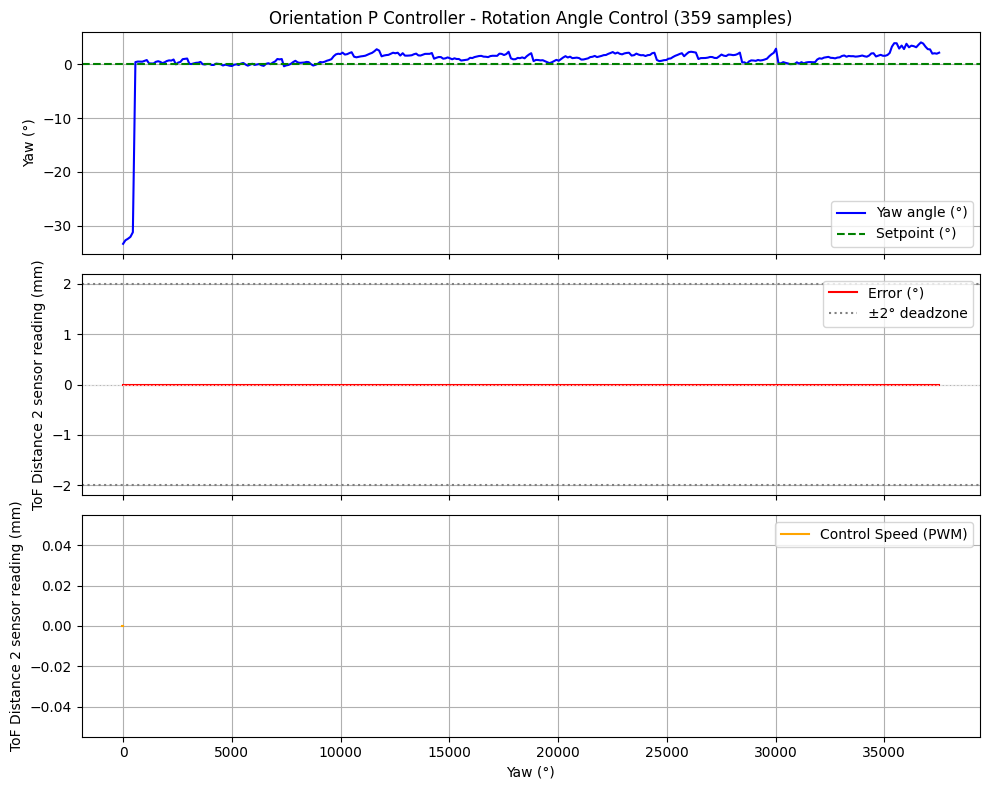

Run duration:   37523ms


In [20]:
# plot
T = np.array(T_arr)
T = T - T[0]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Yaw angle data vs time
ax1.plot(T, Yaw_arr, color='blue', label='Yaw angle (°)')
ax1.axhline(y=0, color='green', linestyle='--', label='Setpoint (°)')
ax1.set_ylabel('Yaw (°)')
ax1.legend(); ax1.grid(True)
ax1.set_title(f'Orientation P Controller - Rotation Angle Control ({len(T)} samples)')

# ToF Distance 2 sensor reading vs time
ax2.plot(T, ToF_distance2_arr, color='red', label='Error (°)')
ax2.axhline(y=0, color='white', linestyle='--', linewidth=0.5)
ax2.axhline(y=2,  color='gray',  linestyle=':',  label='±2° deadzone')
ax2.axhline(y=-2, color='gray',  linestyle=':')
ax2.set_ylabel('ToF Distance 2 sensor reading (mm)')
ax2.legend(); ax2.grid(True)

# ToF Distance 2 sensor reading vs Yaw angle data
ax3.plot(Yaw_arr, ToF_distance2_arr, color='orange', label='Control Speed (PWM)')
ax3.set_ylabel('ToF Distance 2 sensor reading (mm)')
ax3.set_xlabel('Yaw (°)')
ax3.legend(); ax3.grid(True)

plt.tight_layout()
plt.show()

# Final result based on controller quality
print(f"Run duration:   {T[-1]}ms")

In [48]:
ble.send_command(CMD_lab9.RESET_YAW, "")
print("Reset Yaw to 0°")

Reset Yaw to 0°
